<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week3/Day3/ExerciseXP/MiniProjet/mini-projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini-projet : Analyse statistique avancée des données boursières d'Apple Inc.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Apple Stock Prices From 1981 to 2023.zip to Apple Stock Prices From 1981 to 2023.zip


In [5]:
import zipfile

with zipfile.ZipFile('Apple Stock Prices From 1981 to 2023.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [6]:
import os

print(os.listdir())

['.config', 'Apple Stock Prices From 1981 to 2023.zip', 'Apple Stock Prices (1981 to 2023).csv', 'sample_data']


In [9]:
import pandas as pd

df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')

print(df.head())
print(df.columns.tolist())
print(df.columns.tolist())

         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [10]:
print(df.info())

print("\nValeurs manquantes :")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB
None

Valeurs manquantes :
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df = df.sort_values('Date')

print(df.head())

        Date      Open      High       Low     Close  Adj Close    Volume
0 1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1 1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2 1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3 1981-01-07  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4 1981-01-08  0.135603  0.135603  0.135045  0.135045   0.105085  39827200


In [12]:
import numpy as np

print(df[['Open','High','Low','Close','Volume']].describe())

print("\nMoyenne Close :", np.mean(df['Close']))
print("Médiane Close :", np.median(df['Close']))
print("Écart-type Close :", np.std(df['Close']))

               Open          High           Low         Close        Volume
count  10608.000000  10608.000000  10608.000000  10608.000000  1.060800e+04
mean      16.689173     16.879955     16.500822     16.697362  3.275098e+08
std       35.450519     35.882848     35.031289     35.473912  3.378203e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.287946      0.296875      0.282355      0.288923  1.213044e+08
50%        0.488839      0.495536      0.480446      0.487701  2.145976e+08
75%       16.320893     16.418483     16.151249     16.269554  4.066804e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09

Moyenne Close : 16.69736201451735
Médiane Close : 0.487701
Écart-type Close : 35.47223956417654


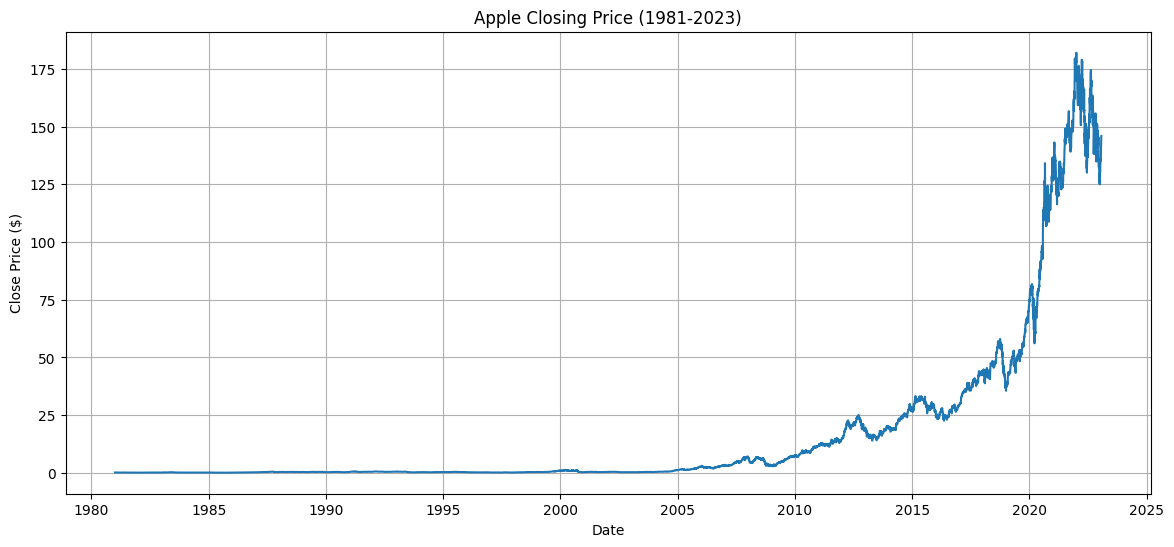

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'])

plt.title('Apple Closing Price (1981-2023)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')

plt.grid()

plt.show()

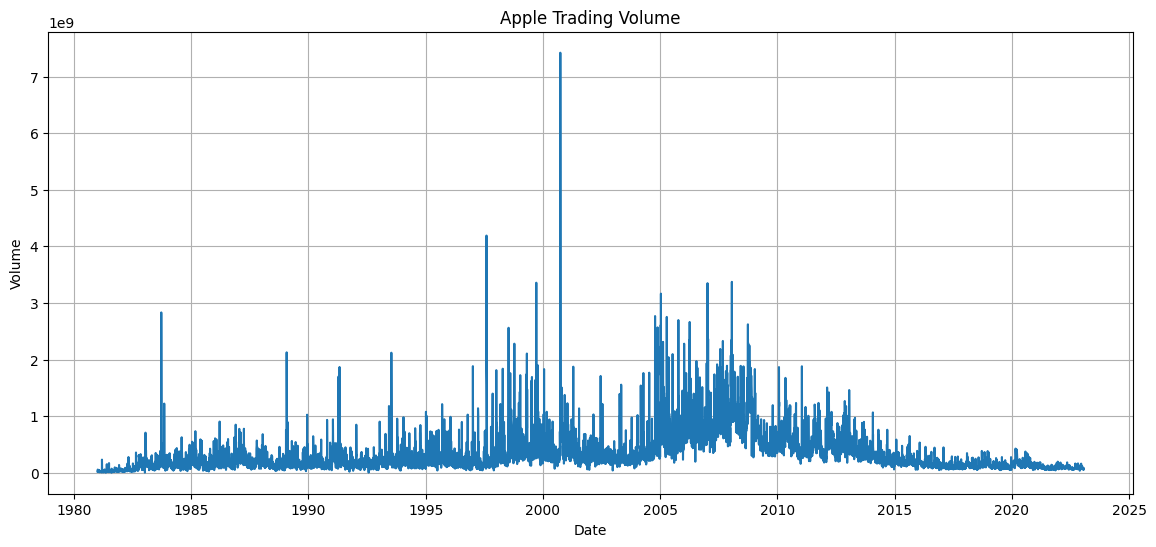

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Volume'])

plt.title('Apple Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.grid()

plt.show()

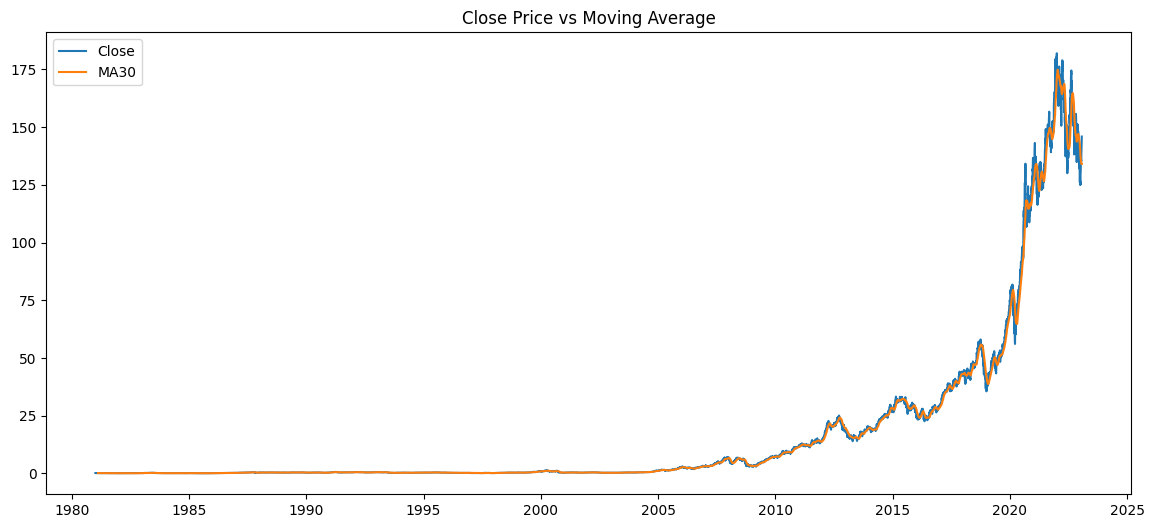

In [15]:
df['MA30'] = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA30'], label='MA30')

plt.legend()

plt.title('Close Price vs Moving Average')

plt.show()

In [16]:
df['Daily Return'] = df['Close'].pct_change()

print(df[['Date','Close','Daily Return']].head())

        Date     Close  Daily Return
0 1981-01-02  0.154018           NaN
1 1981-01-05  0.150670     -0.021738
2 1981-01-06  0.143973     -0.044448
3 1981-01-07  0.137835     -0.042633
4 1981-01-08  0.135045     -0.020242


In [17]:
from scipy.stats import shapiro

returns = df['Daily Return'].dropna()

sample = returns.sample(5000, random_state=42)

stat, p = shapiro(sample)

print("Statistic =", stat)
print("P-value =", p)

if p < 0.05:
    print("Les rendements ne suivent pas une loi normale")
else:
    print("Les rendements suivent une loi normale")

Statistic = 0.9531905652536145
P-value = 2.7030255596048615e-37
Les rendements ne suivent pas une loi normale


In [23]:
from scipy.stats import ttest_ind

df['Year'] = df['Date'].dt.year

close_2022 = df[df['Year'] == 2022]['Close']
close_2023 = df[df['Year'] == 2023]['Close']

t_stat, p_value = ttest_ind(close_2022, close_2023)

print("T-statistic :", t_stat)
print("P-value :", p_value)


T-statistic : 6.4128167393735716
P-value : 6.456957567365956e-10
[[ 1.         -0.21493343]
 [-0.21493343  1.        ]]


In [19]:
if p_value < 0.05:
    print("Les moyennes sont significativement différentes")
else:
    print("Aucune différence significative")

Les moyennes sont significativement différentes


In [20]:
corr = np.corrcoef(
    df['Close'],
    df['Volume']
)

print(corr)

[[ 1.         -0.21493343]
 [-0.21493343  1.        ]]


In [21]:
corr[0,1]

np.float64(-0.21493342533575596)

In [24]:
print("=== EXECUTIVE SUMMARY ===")

print(f"Nombre d'observations : {len(df)}")

print(f"Prix moyen : {df['Close'].mean():.2f}")

print(f"Prix maximum : {df['Close'].max():.2f}")

print(f"Prix minimum : {df['Close'].min():.2f}")

print(f"Volume moyen : {df['Volume'].mean():,.0f}")

print(f"Corrélation Prix-Volume : {corr[0,1]:.3f}")
corr = np.corrcoef(df['Close'], df['Volume'])

print(corr)

=== EXECUTIVE SUMMARY ===
Nombre d'observations : 10608
Prix moyen : 16.70
Prix maximum : 182.01
Prix minimum : 0.05
Volume moyen : 327,509,817
Corrélation Prix-Volume : -0.215
[[ 1.         -0.21493343]
 [-0.21493343  1.        ]]


# Apple Stock Statistical Analysis (1981–2023)

## 1. Data Loading and Exploration

### Objective
Load the Apple stock dataset and inspect its structure.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, shapiro

df = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')

print(df.head())
print(df.info())
print(df.isnull().sum())
```

### Date Conversion

```python
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
```

---

## 2. Data Visualization

### Closing Price Over Time

```python
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title('Apple Closing Price (1981-2023)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid()
plt.show()
```

### Trading Volume Over Time

```python
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'])
plt.title('Apple Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid()
plt.show()
```

---

## 3. Statistical Analysis

### Descriptive Statistics

```python
print(df[['Open','High','Low','Close','Volume']].describe())
```

### Mean, Median and Standard Deviation

```python
print("Mean:", np.mean(df['Close']))
print("Median:", np.median(df['Close']))
print("Standard Deviation:", np.std(df['Close']))
```

### Moving Average (30 Days)

```python
df['MA30'] = df['Close'].rolling(30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA30'], label='MA30')
plt.legend()
plt.title('Closing Price and 30-Day Moving Average')
plt.show()
```

### Interpretation

The moving average smooths short-term fluctuations and highlights long-term trends in Apple's stock performance.

---

## 4. Hypothesis Testing

### Comparing 2022 and 2023 Closing Prices

#### Hypotheses

- H₀: Average closing prices are equal.
- H₁: Average closing prices are different.

```python
df['Year'] = df['Date'].dt.year

close_2022 = df[df['Year'] == 2022]['Close']
close_2023 = df[df['Year'] == 2023]['Close']

t_stat, p_value = ttest_ind(close_2022, close_2023)

print("T-statistic :", t_stat)
print("P-value :", p_value)
```

### Interpretation

Result:

```text
T-statistic : 6.4128
P-value : 6.4569e-10
```

Since the p-value is below 0.05, we reject the null hypothesis.

There is a statistically significant difference between the average closing prices in 2022 and 2023.

---

## 5. Daily Returns and Normality Test

### Calculate Daily Returns

```python
df['Daily Return'] = df['Close'].pct_change()
returns = df['Daily Return'].dropna()
```

### Shapiro-Wilk Test

```python
sample = returns.sample(5000, random_state=42)

stat, p = shapiro(sample)

print("Statistic =", stat)
print("P-value =", p)
```

### Interpretation

Result:

```text
Statistic = 0.953
P-value = 2.703e-37
```

Since the p-value is much lower than 0.05, the daily returns do not follow a normal distribution.

This is common in financial markets where extreme movements occur more frequently than predicted by a normal distribution.

---

## 6. Correlation Analysis

### Correlation Between Price and Volume

```python
corr = np.corrcoef(df['Close'], df['Volume'])

print(corr)
```

Result:

```text
[[ 1.         -0.21493343]
 [-0.21493343  1.        ]]
```

### Interpretation

The correlation coefficient is:

```python
print(corr[0,1])
```

Result:

```text
-0.215
```

This indicates a weak negative relationship between stock prices and trading volume.

---

## 7. Executive Summary

### Key Findings

- Dataset contains 10,608 observations.
- Average closing price: $16.70.
- Maximum closing price: $182.01.
- Minimum closing price: $0.05.
- Average trading volume: 327,509,817 shares.
- Daily returns do not follow a normal distribution.
- Closing prices differ significantly between 2022 and 2023.
- Correlation between price and volume is weakly negative (-0.215).

---

## 8. Reflection

During this project, I learned how to combine Pandas, NumPy, SciPy, and Matplotlib to analyze financial data.

The main challenge was handling a large time-series dataset and interpreting statistical tests correctly.

Using Pandas simplified data preparation, NumPy provided efficient numerical calculations, SciPy enabled hypothesis testing, and Matplotlib made trend visualization straightforward.

The analysis revealed that Apple stock returns are not normally distributed and that stock prices changed significantly between 2022 and 2023. These findings illustrate the importance of statistical analysis when studying financial markets.